# LAB 03 - HOUSE PRICES: ADVANCED REGRESSION TECHNIQUES
## 01. KHÁM PHÁ DỮ LIỆU (EDA) VÀ XÁC ĐỊNH BÀI TOÁN
**Người thực hiện:** Bùi Đức Trường 
**Môn học:** Học Sâu

**Tài liệu tham khảo cốt lõi:** Dean De Cock (2011), *Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project*, Journal of Statistics Education, Vol. 19, No. 3.

---
### Mục tiêu của Notebook:
1. Đọc và khảo sát cấu trúc tập dữ liệu nhà ở Ames Housing (Kaggle House Prices).
2. Phân tích phân phối của biến mục tiêu `SalePrice` và cơ sở toán học của phép biến đổi $\log(1 + \text{SalePrice})$.
3. Khảo sát ngoại lai (Outliers) theo bài báo Dean De Cock (2011) và đưa ra quyết định xử lý.
4. Thống kê, phân loại các giá trị thiếu (Missing Values) và các nhóm đặc trưng.
5. Phân tích tương quan (Correlation) tìm ra các thuộc tính quan trọng nhất ảnh hưởng đến giá trị bất động sản.
6. Thiết lập các kết luận định hướng kỹ thuật cho toàn nhóm (tiền đề cho Feature Engineering và Modeling).


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cấu hình thẩm mỹ đồ thị thuần Matplotlib
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['grid.linestyle'] = '--'

# Đảm bảo thư mục lưu figures tồn tại
fig_dir = Path('../figures')
fig_dir.mkdir(parents=True, exist_ok=True)

print("Các thư viện đã được nạp thành công!")


Các thư viện đã được nạp thành công!


In [2]:
# Đọc dữ liệu train và test từ thư mục data
train_path = Path('../data/train.csv')
test_path = Path('../data/test.csv')

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Kích thước tập Train: {train_df.shape[0]} dòng, {train_df.shape[1]} cột")
print(f"Kích thước tập Test:  {test_df.shape[0]} dòng, {test_df.shape[1]} cột")

train_df.head(5)


Kích thước tập Train: 1460 dòng, 81 cột
Kích thước tập Test:  1459 dòng, 80 cột


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Phân tích Phân phối Biến mục tiêu (`SalePrice`) và Biến đổi Log

Trong các bài toán kinh tế lượng và định giá tài sản, giá trị tài sản thường không phân phối chuẩn mà bị lệch phải mạnh (Right-skewed).
- Paper của Dean De Cock (2011) chỉ ra: thị trường nhà ở có phương sai tăng theo giá (Heteroscedasticity - biên độ giá nhà cao tầng biến động lớn hơn nhiều so với nhà bình dân). Để ổn định phương sai, tác giả khuyến nghị dùng phép biến đổi căn bậc hai hoặc logarit.
- Cuộc thi Kaggle quy định thước đo đánh giá là **RMSLE (Root Mean Squared Logarithmic Error)**:
$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(p_i + 1) - \log(y_i + 1))^2}$$

Do đó, việc biến đổi target sang $y_{log} = \log(1 + \text{SalePrice}) = \text{log1p}(\text{SalePrice})$ đưa bài toán về hồi quy RMSE chuẩn trên phân phối xấp xỉ chuẩn (Gaussian).


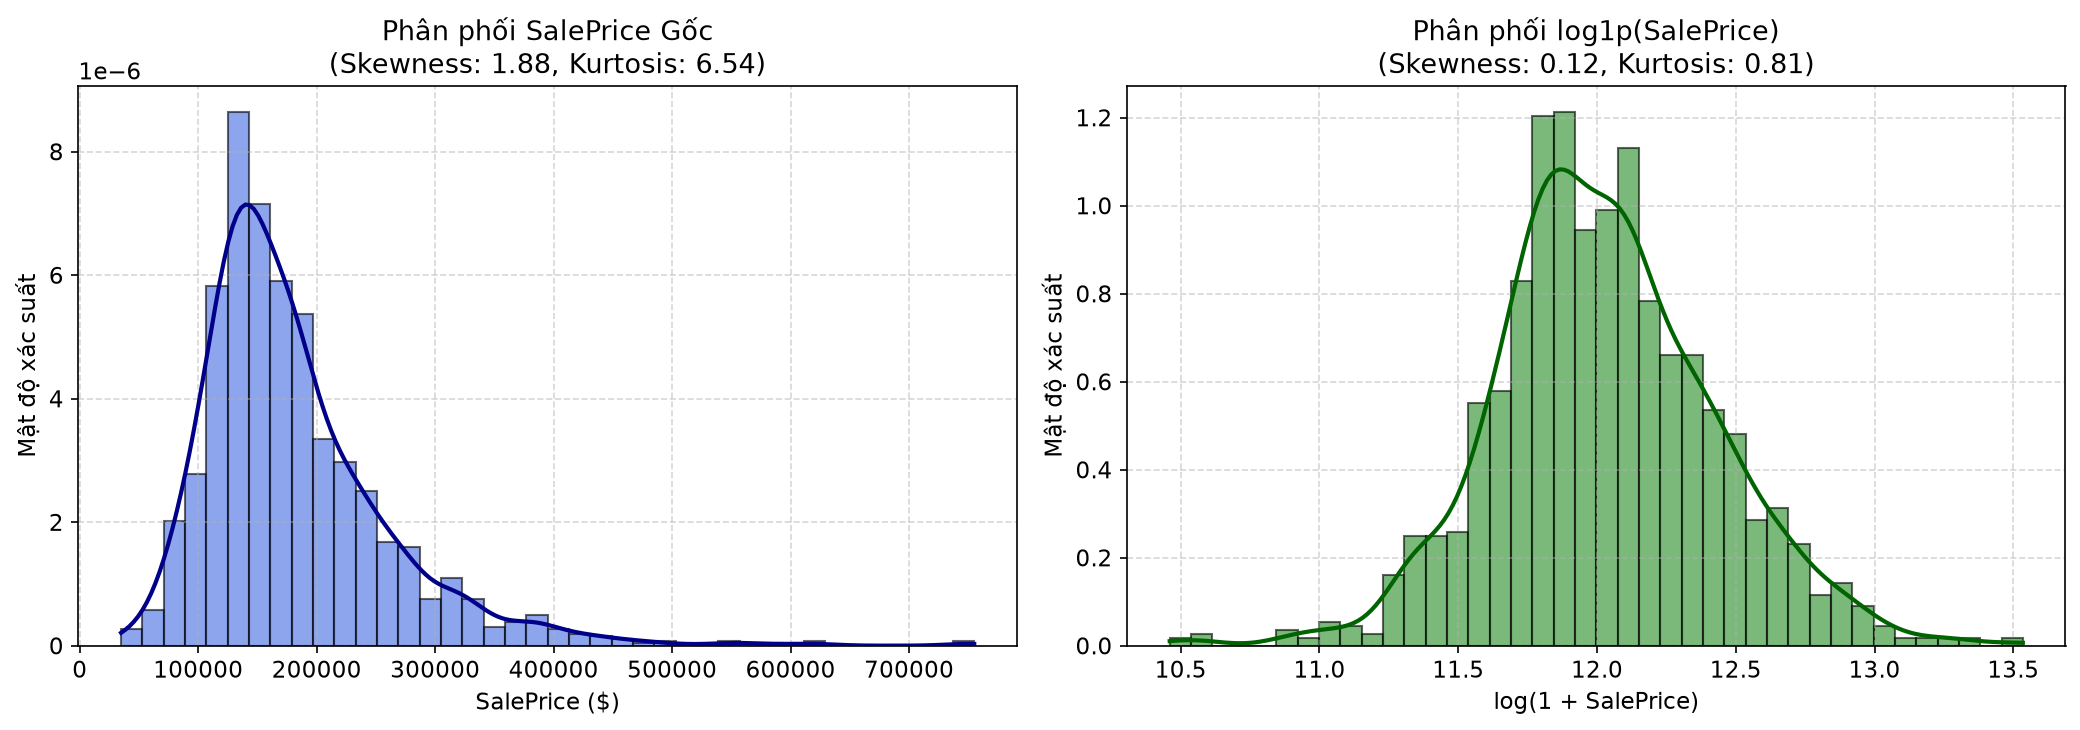

Độ xiên ban đầu: 1.8829 -> Sau log1p: 0.1213 (phân phối xấp xỉ chuẩn)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ giá gốc
sp = train_df['SalePrice']
axes[0].hist(sp, bins=40, density=True, color='royalblue', alpha=0.6, edgecolor='black')
kde_sp = stats.gaussian_kde(sp)
x_sp = np.linspace(sp.min(), sp.max(), 200)
axes[0].plot(x_sp, kde_sp(x_sp), color='darkblue', lw=2)
axes[0].set_title(f"Phân phối SalePrice Gốc\n(Skewness: {sp.skew():.2f}, Kurtosis: {sp.kurt():.2f})")
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Mật độ xác suất')

# 2. Biểu đồ giá sau khi biến đổi log1p
log_sp = np.log1p(sp)
axes[1].hist(log_sp, bins=40, density=True, color='forestgreen', alpha=0.6, edgecolor='black')
kde_log = stats.gaussian_kde(log_sp)
x_log = np.linspace(log_sp.min(), log_sp.max(), 200)
axes[1].plot(x_log, kde_log(x_log), color='darkgreen', lw=2)
axes[1].set_title(f"Phân phối log1p(SalePrice)\n(Skewness: {log_sp.skew():.2f}, Kurtosis: {log_sp.kurt():.2f})")
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Mật độ xác suất')

plt.tight_layout()
plt.savefig(fig_dir / '01_target_distribution.png', dpi=300)
plt.show()

print(f"Độ xiên ban đầu: {sp.skew():.4f} -> Sau log1p: {log_sp.skew():.4f} (phân phối xấp xỉ chuẩn)")


## 2. Phân tích Điểm Ngoại lai (Outliers) theo Paper Dean De Cock (2011)

Tại trang 4 của bài báo gốc, tác giả Dean De Cock có ghi chú:
> *"Although all known errors were corrected in the data, no observations have been removed due to unusual values... There are five observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will quickly indicate these points). Three of them are true outliers (Partial Sales that likely don't represent actual market values) and two of them are simply unusual sales... I would recommend removing any houses with more than 4000 square feet from the data set."*

Chúng ta vẽ đồ thị phân tán giữa diện tích sinh hoạt trên mặt đất (`GrLivArea`) và giá bán (`SalePrice`) để quan sát các điểm này.


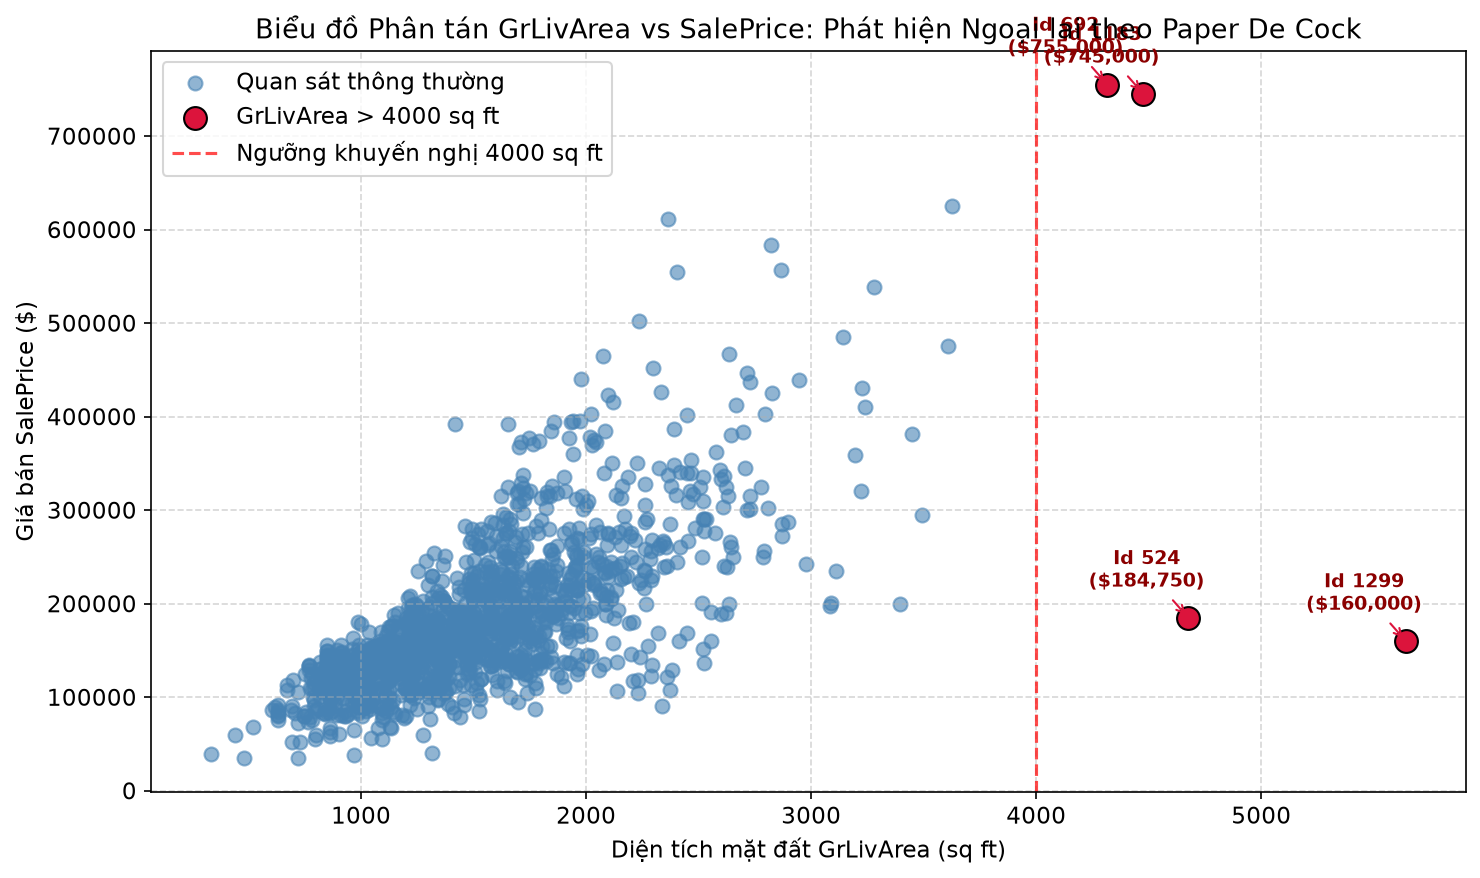

Thông tin chi tiết các căn nhà có GrLivArea > 4000 sq ft:


,Id,GrLivArea,SalePrice,SaleCondition,OverallQual,YearBuilt
523,524,4676,184750,Partial,10,2007
691,692,4316,755000,Normal,10,1994
1182,1183,4476,745000,Abnorml,10,1996
1298,1299,5642,160000,Partial,10,2008


In [4]:
plt.figure(figsize=(10, 6))

# Vẽ scatter plot bằng matplotlib
plt.scatter(train_df['GrLivArea'], train_df['SalePrice'], color='steelblue', alpha=0.6, s=45, label='Quan sát thông thường')

# Tìm các căn nhà có GrLivArea > 4000
outliers_4000 = train_df[train_df['GrLivArea'] > 4000]

# Highlight các điểm ngoại lai > 4000
plt.scatter(outliers_4000['GrLivArea'], outliers_4000['SalePrice'], color='crimson', s=120, edgecolors='black', label='GrLivArea > 4000 sq ft')

for _, row in outliers_4000.iterrows():
    plt.annotate(f"Id {int(row['Id'])}\n(${int(row['SalePrice']):,})", 
                 (row['GrLivArea'], row['SalePrice']),
                 textcoords="offset points", xytext=(-20, 15), ha='center',
                 fontsize=9, weight='bold', color='darkred',
                 arrowprops=dict(arrowstyle="->", color='crimson'))

plt.axvline(x=4000, color='red', linestyle='--', alpha=0.7, label='Ngưỡng khuyến nghị 4000 sq ft')
plt.title("Biểu đồ Phân tán GrLivArea vs SalePrice: Phát hiện Ngoại lai theo Paper De Cock", fontsize=13)
plt.xlabel("Diện tích mặt đất GrLivArea (sq ft)")
plt.ylabel("Giá bán SalePrice ($)")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / '02_outliers_grlivarea.png', dpi=300)
plt.show()

print("Thông tin chi tiết các căn nhà có GrLivArea > 4000 sq ft:")
outliers_4000[['Id', 'GrLivArea', 'SalePrice', 'SaleCondition', 'OverallQual', 'YearBuilt']]


## 3. Khảo sát và Phân loại Dữ liệu Thiếu (Missing Values)

Trong bộ dữ liệu Ames Housing, việc hiểu đúng ý nghĩa của giá trị `NA` là cực kỳ quan trọng:
- Với nhiều trường thuộc tính chất lượng (như `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `GarageType`, `BsmtQual`), ký hiệu `NA` **không phải là dữ liệu bị mất**, mà mang ý nghĩa là **ngôi nhà đó không có hạng mục này** (ví dụ: không có bể bơi, không có lò sưởi, không có gara).
- Nếu điền thiếu bằng mode (giá trị phổ biến nhất), ta sẽ vô tình biến những nhà không có bể bơi thành nhà có bể bơi!
- Vì vậy:
  - Các biến thiếu trên 70% (`PoolQC`, `MiscFeature`, `Alley`, `Fence`) có thể loại bỏ hoặc mã hóa nhị phân ("Có/Không").
  - Các biến phân loại về tiện ích bị thiếu nên được điền giá trị rõ ràng là `"None"`.


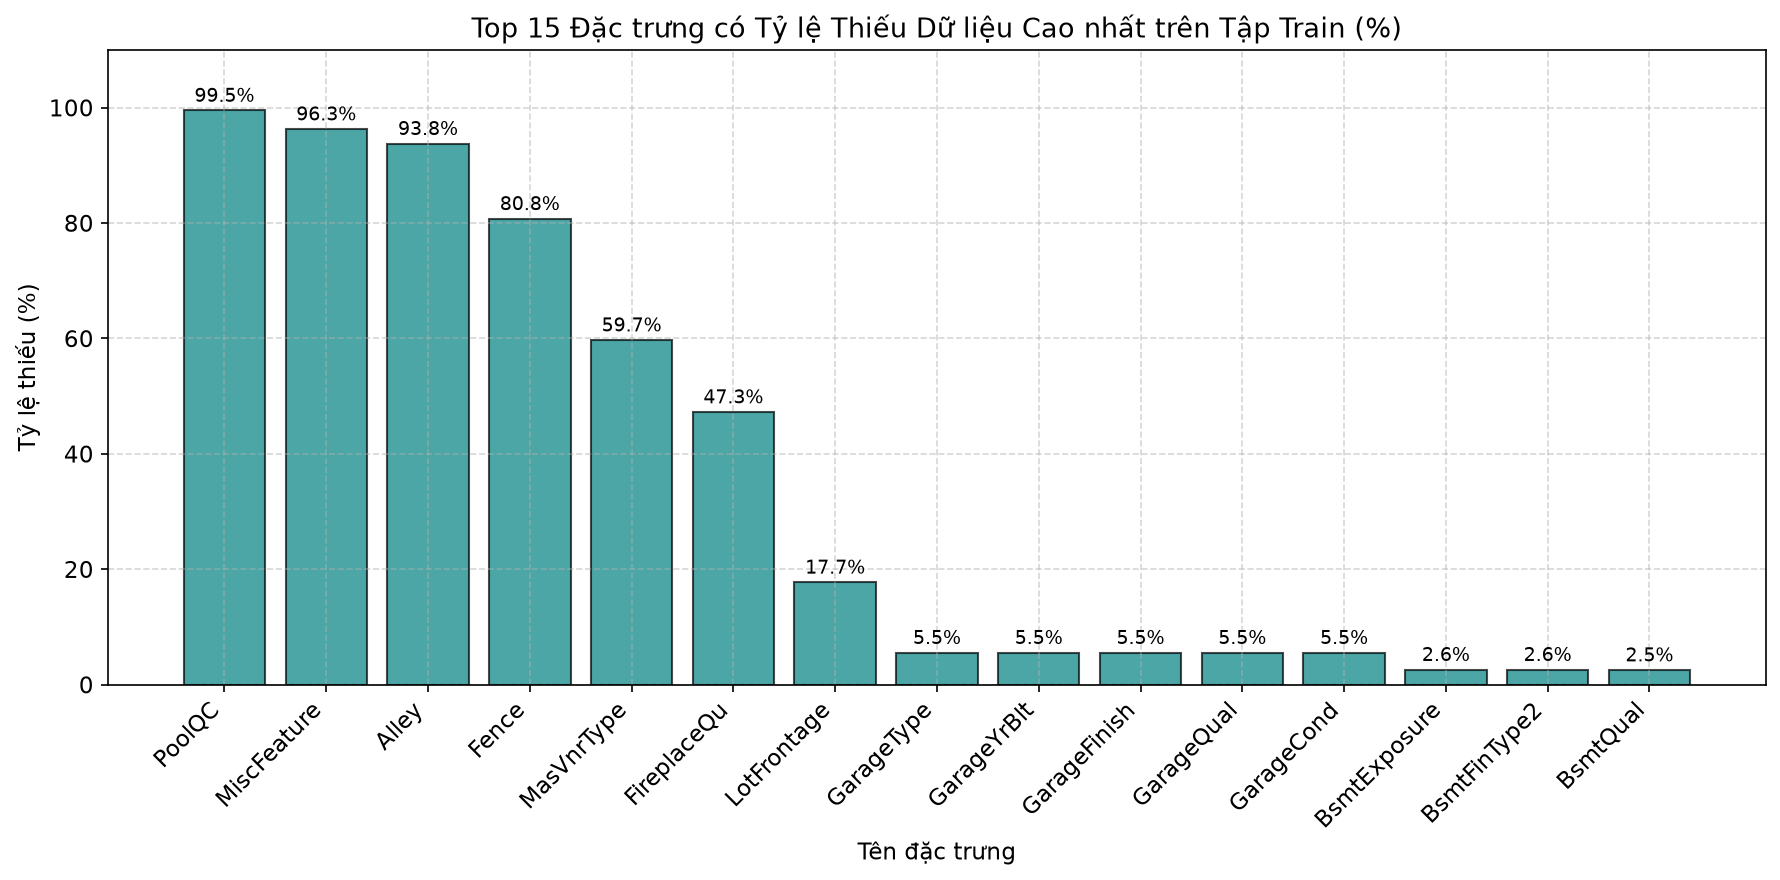

Tổng số cột có giá trị thiếu trong tập Train: 19 / 81 cột


In [5]:
# Tính tỷ lệ missing values trên tập Train
missing_counts = train_df.isnull().sum()
missing_percent = (missing_counts / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percent', ascending=False)

plt.figure(figsize=(12, 6))
top_missing = missing_df.head(15)
bars = plt.bar(range(len(top_missing)), top_missing['Percent'], color='teal', edgecolor='black', alpha=0.7)
plt.xticks(range(len(top_missing)), top_missing.index, rotation=45, ha='right')
plt.title("Top 15 Đặc trưng có Tỷ lệ Thiếu Dữ liệu Cao nhất trên Tập Train (%)", fontsize=13)
plt.ylabel("Tỷ lệ thiếu (%)")
plt.xlabel("Tên đặc trưng")

for i, bar in enumerate(bars):
    v = top_missing['Percent'].iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.ylim(0, 110)
plt.tight_layout()
plt.savefig(fig_dir / '03_missing_values.png', dpi=300)
plt.show()

print(f"Tổng số cột có giá trị thiếu trong tập Train: {len(missing_df)} / {train_df.shape[1]} cột")


## 4. Phân tích Tương quan (Correlation) với LogSalePrice

Nhóm trích xuất các biến định lượng (numerical features) và tính hệ số tương quan Pearson với $\log(1 + \text{SalePrice})$ để xác định những yếu tố có sức mạnh dự báo cao nhất.


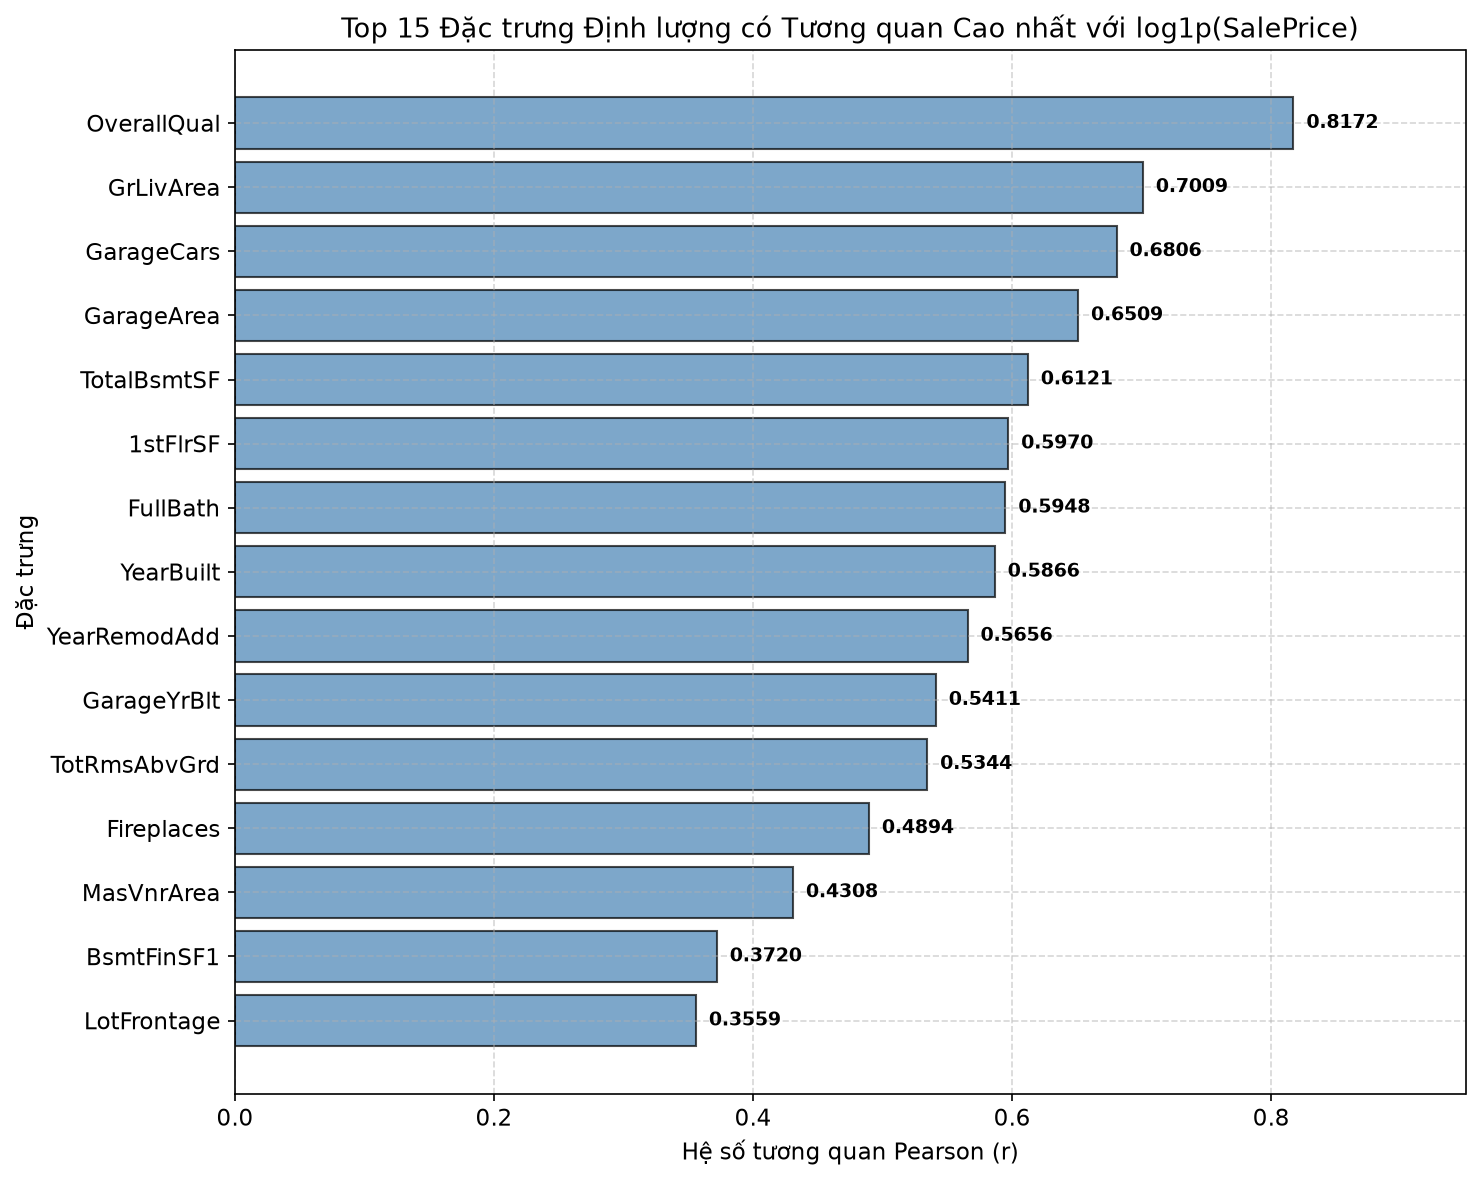

Top 10 biến có tương quan mạnh nhất:


OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
Name: LogSalePrice, dtype: float64

In [6]:
# Thêm cột tạm log1p(SalePrice) để tính tương quan
train_analysis = train_df.copy()
train_analysis['LogSalePrice'] = np.log1p(train_analysis['SalePrice'])

# Chọn các biến số
num_cols = train_analysis.select_dtypes(include=[np.number]).columns
corr_matrix = train_analysis[num_cols].corr()

# Lấy tương quan với LogSalePrice (loại trừ chính nó và SalePrice, Id)
target_corr = corr_matrix['LogSalePrice'].drop(['LogSalePrice', 'SalePrice', 'Id']).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
top15_corr = target_corr.head(15)
plt.barh(range(len(top15_corr)), top15_corr.values[::-1], color='steelblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top15_corr)), top15_corr.index[::-1])
plt.title("Top 15 Đặc trưng Định lượng có Tương quan Cao nhất với log1p(SalePrice)", fontsize=13)
plt.xlabel("Hệ số tương quan Pearson (r)")
plt.ylabel("Đặc trưng")

for i, v in enumerate(top15_corr.values[::-1]):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=9, weight='bold')

plt.xlim(0, 0.95)
plt.tight_layout()
plt.savefig(fig_dir / '04_top_correlations.png', dpi=300)
plt.show()

print("Top 10 biến có tương quan mạnh nhất:")
top15_corr.head(10)


## 5. Phân tích Sâu 2 Đặc trưng Then chốt: OverallQual & Neighborhood

- **OverallQual (Chất lượng vật liệu và hoàn thiện):** Là biến có tương quan mạnh nhất ($r = 0.817$). Đánh giá từ 1 (Rất kém) đến 10 (Rất xuất sắc).
- **Neighborhood (Khu vực vị trí địa lý):** Trong bất động sản, vị trí là yếu tố quyết định hàng đầu. Mức giá trung bình giữa các khu vực có sự phân hóa rất lớn.


C:\Users\XIAOXIN\AppData\Local\Temp\ipykernel_8028\4205723993.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data_by_neigh, tick_labels=order_neigh, vert=True)


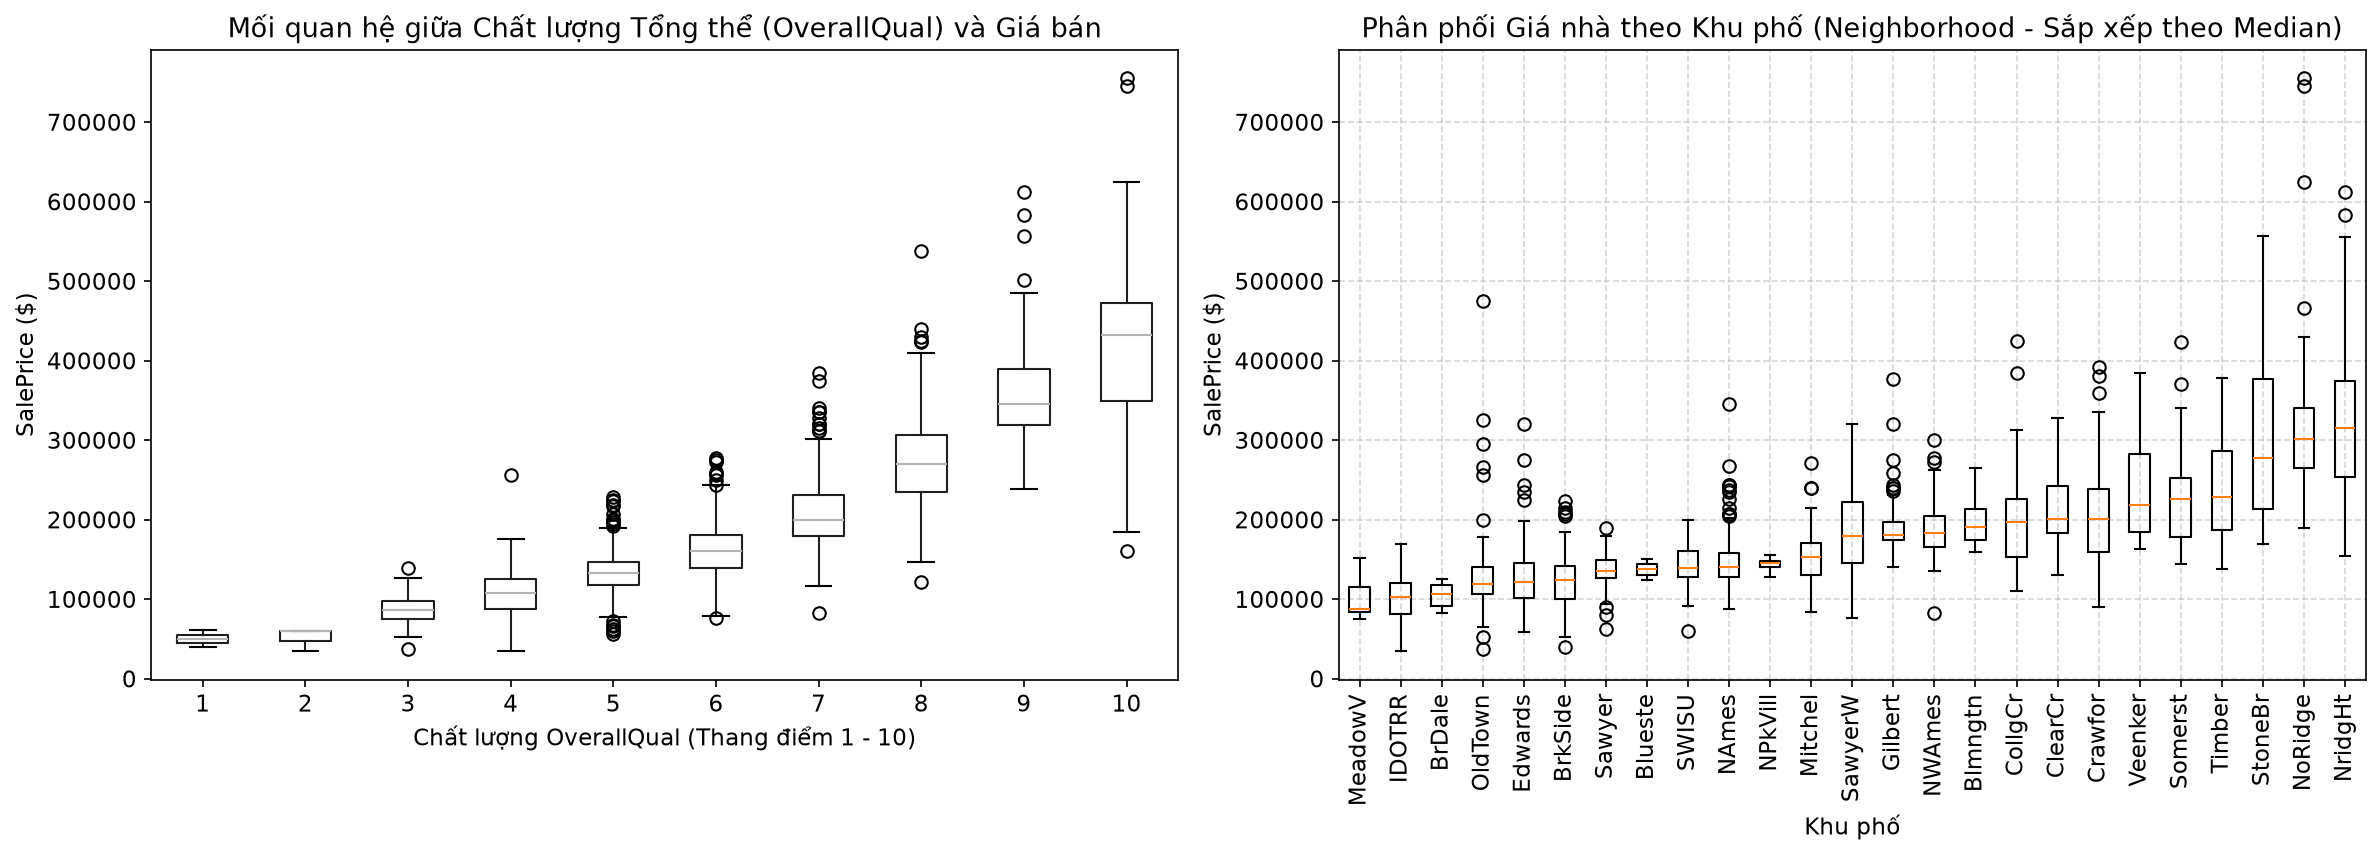

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot giá nhà theo OverallQual bằng pandas
train_df.boxplot(column='SalePrice', by='OverallQual', ax=axes[0], grid=False)
axes[0].set_title("Mối quan hệ giữa Chất lượng Tổng thể (OverallQual) và Giá bán")
axes[0].set_xlabel("Chất lượng OverallQual (Thang điểm 1 - 10)")
axes[0].set_ylabel("SalePrice ($)")

# 2. Boxplot giá nhà theo Neighborhood sắp xếp theo median
order_neigh = train_df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
data_by_neigh = [train_df[train_df['Neighborhood'] == n]['SalePrice'].values for n in order_neigh]

axes[1].boxplot(data_by_neigh, tick_labels=order_neigh, vert=True)
axes[1].set_title("Phân phối Giá nhà theo Khu phố (Neighborhood - Sắp xếp theo Median)")
axes[1].set_xlabel("Khu phố")
axes[1].set_ylabel("SalePrice ($)")
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle("")
plt.tight_layout()
plt.savefig(fig_dir / '05_quality_and_neighborhood.png', dpi=300)
plt.show()


## 6. KẾT LUẬN & ĐỊNH HƯỚNG KỸ THUẬT CHO CÁC BƯỚC TIẾP THEO

Qua quá trình khám phá dữ liệu (EDA) và đối chiếu với bài báo của Dean De Cock (2011), nhóm trưởng rút ra các quyết định kỹ thuật nền tảng:

1. **Về Biến mục tiêu:**
   - Bắt buộc hồi quy trên $y = \log(1 + \text{SalePrice})$.
   - Khi tính sai số và nộp Kaggle, dùng hàm $\text{expm1}(y)$ để khôi phục về giá USD thực tế.
   - Metric theo dõi chính: **RMSLE** (trên log scale) và **MAE** (trên giá gốc USD).

2. **Về Xử lý Ngoại lai (Outliers):**
   - Áp dụng đúng chỉ dẫn của bài báo: Loại bỏ 2 quan sát ngoại lai cực đoan trong tập Train có $GrLivArea > 4000$ sq ft với giá thấp bất thường (giao dịch Partial: **Id 524** và **Id 1299**).
   - Tuyệt đối không xóa dòng nào trên tập Test.

3. **Về Tiền xử lý (Preprocessing & Leakage Prevention):**
   - Loại bỏ các cột thiếu quá nhiều: `Alley`, `PoolQC`, `Fence`, `MiscFeature` và cột định danh `Id`.
   - Biến số: Impute bằng `median`, chuẩn hóa bằng `StandardScaler`.
   - Biến phân loại: Impute bằng giá trị `"None"` đối với tiện ích, mã hóa bằng `OneHotEncoder(handle_unknown='ignore')`.
   - Toàn bộ pipeline tiền xử lý **chỉ fit trên từng Train Fold** của 5-Fold Cross Validation.

4. **Kế hoạch chuyển giao cho các thành viên:**
   - **Thanh Tuyền:** Tiếp nhận dữ liệu sạch, tiến hành tạo 6 biến phái sinh (`TotalSF`, `TotalBathrooms`, `TotalPorchSF`, `HouseAge`, `RemodAge`, `GarageAge`) và thiết kế 5 thực nghiệm EXP-00 $	o$ EXP-04.
   - **Nguyễn Thị Ánh Trâm & Ngọc Trúc:** Nhận 5 gói thực nghiệm từ Tuyền, chạy song song 2 họ mô hình: **Scikit-learn** và **PyTorch MLP** trên cùng bộ 5-Fold Cross Validation.

---
*(Hoàn thành Notebook 01)*
